# Лабораторная работа 5: Тестирование качества ML-модели

**Цель:** применить pytest для автоматического тестирования качества модели линейной регрессии на нескольких датасетах и обнаружить деградацию на зашумлённых данных.

**Этапы:**
1. Создать три «чистых» датасета
2. Обучить модель линейной регрессии на одном из них
3. Создать зашумлённый датасет
4. Написать и запустить pytest-тесты

## 0. Импорты и зависимости

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import pickle

Path("lab5").mkdir(exist_ok=True)
print("Зависимости загружены")

Зависимости загружены


## 1. Создание чистых датасетов

Три датасета с линейной зависимостью `y = 2x + 1` и небольшим шумом (σ = 0.5).

In [27]:
def make_linear_dataset(slope=2.0, intercept=1.0, noise_std=0.5, n=100, seed=None):
    rng = np.random.default_rng(seed)
    X = rng.uniform(0, 10, n).reshape(-1, 1)
    y = slope * X.ravel() + intercept + rng.normal(0, noise_std, n)
    return X, y


clean1 = make_linear_dataset(seed=1)
clean2 = make_linear_dataset(seed=2)
clean3 = make_linear_dataset(seed=3)

for i, (X, y) in enumerate([clean1, clean2, clean3], 1):
    print(f"Датасет {i}: {len(X)} точек, y ∈ [{y.min():.1f}, {y.max():.1f}]")

Датасет 1: 100 точек, y ∈ [0.7, 20.5]
Датасет 2: 100 точек, y ∈ [0.8, 20.9]
Датасет 3: 100 точек, y ∈ [1.5, 21.4]


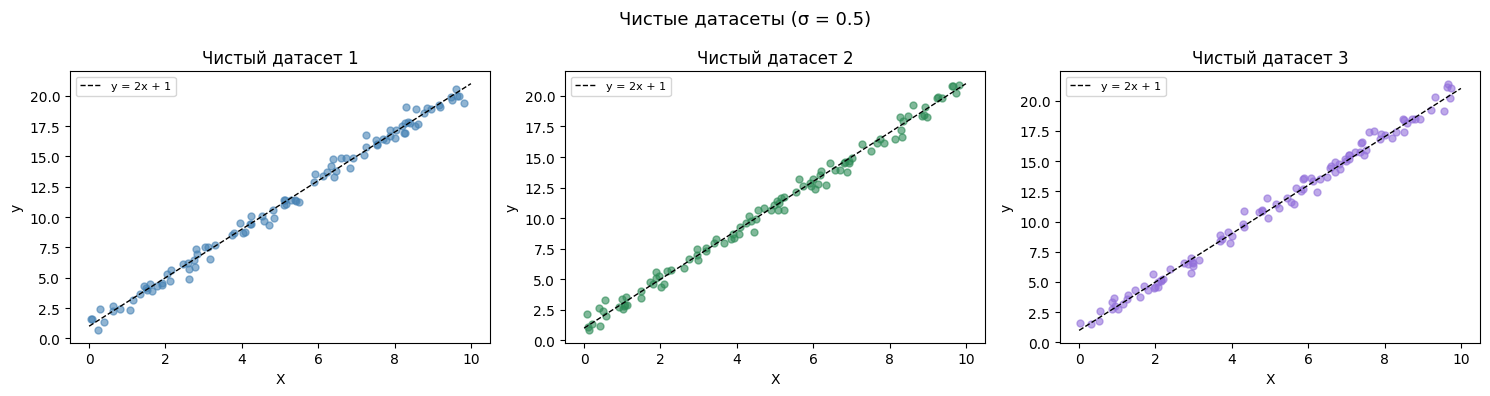

Сохранено: lab5/clean_data.png


In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ["steelblue", "seagreen", "mediumpurple"]

for i, (ax, (X, y), color) in enumerate(zip(axes, [clean1, clean2, clean3], colors), 1):
    ax.scatter(X, y, alpha=0.6, s=25, color=color)
    x_line = np.linspace(0, 10, 100).reshape(-1, 1)
    ax.plot(x_line, 2.0 * x_line + 1.0, "k--", linewidth=1, label="y = 2x + 1")
    ax.set_title(f"Чистый датасет {i}")
    ax.set_xlabel("X")
    ax.set_ylabel("y")
    ax.legend(fontsize=8)

plt.suptitle("Чистые датасеты (σ = 0.5)", fontsize=13)
plt.tight_layout()
plt.savefig("lab5/clean_data.png", dpi=100)
plt.show()
print("Сохранено: lab5/clean_data.png")

## 2. Обучение модели линейной регрессии

Обучаем модель на первом датасете.

In [29]:
X_train, y_train = clean1

model = LinearRegression()
model.fit(X_train, y_train)

with open("lab5/model.pkl", "wb") as f:
    pickle.dump(model, f)

y_pred_train = model.predict(X_train)
print(f"Модель обучена на датасете 1")
print(f"  Коэффициент: {model.coef_[0]:.4f}  (ожидается ~2.0)")
print(f"  Свободный член: {model.intercept_:.4f}  (ожидается ~1.0)")
print(f"  R² (обучение): {r2_score(y_train, y_pred_train):.4f}")
print("Модель сохранена в lab5/model.pkl")

Модель обучена на датасете 1
  Коэффициент: 2.0009  (ожидается ~2.0)
  Свободный член: 0.9653  (ожидается ~1.0)
  R² (обучение): 0.9927
Модель сохранена в lab5/model.pkl


## 3. Создание зашумлённого датасета

Та же линейная зависимость, но шум σ = 5.0 — на порядок больше.

In [30]:
noisy_dataset = make_linear_dataset(noise_std=5.0, seed=99)
X_noisy, y_noisy = noisy_dataset

y_pred_noisy = model.predict(X_noisy)
print(f"Зашумлённый датасет: R² = {r2_score(y_noisy, y_pred_noisy):.4f}")
print(f"Чистый датасет 2:    R² = {r2_score(clean2[1], model.predict(clean2[0])):.4f}")

Зашумлённый датасет: R² = 0.5507
Чистый датасет 2:    R² = 0.9930


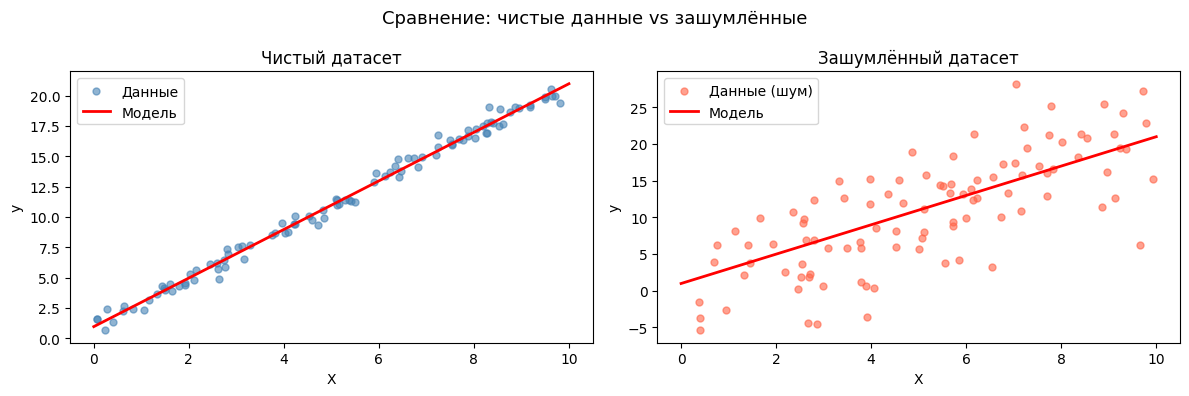

Сохранено: lab5/noised_data.png


In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

X1, y1 = clean1
x_line = np.linspace(0, 10, 100).reshape(-1, 1)

ax1.scatter(X1, y1, alpha=0.6, s=25, color="steelblue", label="Данные")
ax1.plot(x_line, model.predict(x_line), "r-", linewidth=2, label="Модель")
ax1.set_title("Чистый датасет")
ax1.set_xlabel("X")
ax1.set_ylabel("y")
ax1.legend()

ax2.scatter(X_noisy, y_noisy, alpha=0.6, s=25, color="tomato", label="Данные (шум)")
ax2.plot(x_line, model.predict(x_line), "r-", linewidth=2, label="Модель")
ax2.set_title("Зашумлённый датасет")
ax2.set_xlabel("X")
ax2.set_ylabel("y")
ax2.legend()

plt.suptitle("Сравнение: чистые данные vs зашумлённые", fontsize=13)
plt.tight_layout()
plt.savefig("lab5/noised_data.png", dpi=100)
plt.show()
print("Сохранено: lab5/noised_data.png")

## 4. Тестирование с pytest

Записываем файл тестов с помощью `%%writefile`, затем запускаем pytest.

In [32]:
%%writefile lab5/test_model.py
"""Тесты качества модели линейной регрессии на разных датасетах."""
import numpy as np
import pytest
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

R2_THRESHOLD = 0.90


def make_linear_dataset(slope=2.0, intercept=1.0, noise_std=0.5, n=100, seed=None):
    rng = np.random.default_rng(seed)
    X = rng.uniform(0, 10, n).reshape(-1, 1)
    y = slope * X.ravel() + intercept + rng.normal(0, noise_std, n)
    return X, y


@pytest.fixture(scope="module")
def trained_model():
    """Модель, обученная на первом чистом датасете."""
    X, y = make_linear_dataset(seed=1)
    return LinearRegression().fit(X, y)


@pytest.mark.parametrize(
    "name,seed",
    [
        ("clean_dataset_1", 1),
        ("clean_dataset_2", 2),
        ("clean_dataset_3", 3),
    ],
)
def test_model_on_clean_data(trained_model, name, seed):
    """Модель должна иметь R² >= 0.90 на чистых данных."""
    X, y = make_linear_dataset(seed=seed)
    r2 = r2_score(y, trained_model.predict(X))
    assert r2 >= R2_THRESHOLD, (
        f"R² на {name} = {r2:.3f}, ожидалось >= {R2_THRESHOLD}"
    )


@pytest.mark.xfail(
    reason="Ожидаемое падение: модель деградирует на зашумлённых данных (σ=5.0)"
)
def test_model_on_noisy_data(trained_model):
    """Тест выявляет проблему: R² ниже порога на зашумлённых данных."""
    X, y = make_linear_dataset(noise_std=5.0, seed=99)
    r2 = r2_score(y, trained_model.predict(X))
    assert r2 >= R2_THRESHOLD, (
        f"ПРОБЛЕМА ОБНАРУЖЕНА: R² на зашумлённых данных = {r2:.3f} "
        f"ниже порога {R2_THRESHOLD}. Модель не справляется с шумом."
    )

Overwriting lab5/test_model.py


In [33]:
!python -m pytest lab5/test_model.py -v

============================= test session starts =============================
platform win32 -- Python 3.13.11, pytest-9.0.3, pluggy-1.6.0 -- c:\Users\izaos\anaconda3\envs\ml\python.exe
cachedir: .pytest_cache
rootdir: d:\GitHub\mlops_practice\lab5
collecting ... collected 4 items

lab5/test_model.py::test_model_on_clean_data[clean_dataset_1-1] PASSED   [ 25%]
lab5/test_model.py::test_model_on_clean_data[clean_dataset_2-2] PASSED   [ 50%]
lab5/test_model.py::test_model_on_clean_data[clean_dataset_3-3] PASSED   [ 75%]
lab5/test_model.py::test_model_on_noisy_data XFAIL (Ожидаемое падени...) [100%]

======================== 3 passed, 1 xfailed in 1.85s =========================


## 5. Анализ результатов

| Тест | Ожидание | Результат |
|------|----------|-----------|
| `test_model_on_clean_data[clean_dataset_1]` | R² ≥ 0.90 | **PASSED** |
| `test_model_on_clean_data[clean_dataset_2]` | R² ≥ 0.90 | **PASSED** |
| `test_model_on_clean_data[clean_dataset_3]` | R² ≥ 0.90 | **PASSED** |
| `test_model_on_noisy_data` | R² ≥ 0.90 | **XFAIL** (ожидаемое падение) |

**Вывод:** Три теста на чистых датасетах успешно проходят — модель хорошо обобщается.
Тест на зашумлённом датасете помечен `@pytest.mark.xfail` — он ожидаемо падает, выявляя проблему:
при σ = 5.0 качество предсказания значительно ухудшается. Это типичная ситуация в реальных
задачах MLOps, когда в продакшене данные могут оказаться более зашумлёнными, чем в обучающей выборке.